# 🌧️ Predicción de Precipitación con GRU - Dataset JUN
**Modelos:** Predicción a 1h, 3h y 6h  
**Arquitectura:** Gated Recurrent Unit (GRU)  
**Resampleo:** 15 min → 1 hora (promedio para variables continuas, suma para lluvia)

## 1. Importación de Librerías

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f'TensorFlow version: {tf.__version__}')
print(f'Pandas version: {pd.__version__}')

TensorFlow version: 2.21.0
Pandas version: 2.3.3


## 2. Carga del Dataset

In [9]:
# ============================================================
# AJUSTA ESTA RUTA AL ARCHIVO CSV DE TU DATASET JUN
# ============================================================
FILE_PATH = '../Datasets/JUN_consolid_f15.csv'   # <-- cambia aquí

df = pd.read_csv(
    FILE_PATH,
    parse_dates=['TIMESTAMP'],
    index_col='TIMESTAMP',
    na_values=['NA', 'NaN', '']
)

print(f'Shape original: {df.shape}')
print(f'Rango de fechas: {df.index.min()} → {df.index.max()}')
df.head(8)

Shape original: (375325, 53)
Rango de fechas: 2015-06-22 15:00:00 → 2026-03-06 06:00:00


,BattV_Avg,PTemp_C_Avg,LWmV_Avg,Rain_mm_Tot,AirTC_Avg,RH_Max,SlrkW_Avg,SlrMJ_Tot,NR_Wm2_Avg,VW,...,VW_3_Min,PA_uS_3_Max,PA_uS_3_Min,NR_Wm2_Max,NR_Wm2_Min,CNR_Wm2_Max,CNR_Wm2_Min,CNR_Wm2_Avg,RECORD,WindDir_Avg
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2015-06-22 15:00:00,13.340000,21.530000,280.200000,0.0,20.970000,99.9,0.217000,0.048850,191.300000,0.549000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 15:15:00,13.293333,21.606667,291.000000,0.0,21.050000,100.0,0.112000,0.092645,94.896667,0.549000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 15:30:00,13.250000,21.530000,330.933333,0.0,20.900000,100.0,0.085000,0.076796,63.973333,0.547333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 15:45:00,13.196667,21.376667,349.033333,0.0,20.836667,100.0,0.070000,0.063112,51.396667,0.547000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 16:00:00,13.116667,21.253333,338.266667,0.0,20.876667,100.0,0.040333,0.036253,28.443333,0.547000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 16:15:00,13.150000,21.156667,354.033333,0.0,20.766667,100.0,0.057333,0.051879,44.036667,0.546333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 16:30:00,13.063333,21.066667,369.900000,0.0,20.733333,100.0,0.023000,0.020808,14.613333,0.546000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 16:45:00,12.983333,21.020000,398.433333,0.0,20.856667,100.0,0.017000,0.015363,10.841000,0.546000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploración del Dataset (15 min)

In [10]:
print('=== Tipos de datos ===')
print(df.dtypes)
print('\n=== Estadísticas descriptivas ===')
df.describe()

=== Tipos de datos ===
BattV_Avg      float64
PTemp_C_Avg    float64
LWmV_Avg       float64
Rain_mm_Tot    float64
AirTC_Avg      float64
RH_Max         float64
SlrkW_Avg      float64
SlrMJ_Tot      float64
NR_Wm2_Avg     float64
VW             float64
PA_uS          float64
VW_2           float64
PA_uS_2        float64
VW_3           float64
PA_uS_3        float64
WS_ms_Avg      float64
WindDir        float64
BattV_Min      float64
PTemp_C_Max    float64
AirTC_Max      float64
AirTC_Min      float64
RH_Min         float64
RH_Avg         float64
SlrW_Max       float64
SlrW_Min       float64
LWmV_Max       float64
LWmV_Min       float64
LWMDry_Tot     float64
LWMCon_Tot     float64
LWMWet_Tot     float64
WS_ms_Max      float64
WS_ms_Min      float64
WindDir_Max    float64
WindDir_Min    float64
VW_Max         float64
VW_Min         float64
PA_uS_Max      float64
PA_uS_Min      float64
VW_2_Max       float64
VW_2_Min       float64
PA_uS_2_Max    float64
PA_uS_2_Min    float64
VW_3_Max   

,BattV_Avg,PTemp_C_Avg,LWmV_Avg,Rain_mm_Tot,AirTC_Avg,RH_Max,SlrkW_Avg,SlrMJ_Tot,NR_Wm2_Avg,VW,...,VW_3_Min,PA_uS_3_Max,PA_uS_3_Min,NR_Wm2_Max,NR_Wm2_Min,CNR_Wm2_Max,CNR_Wm2_Min,CNR_Wm2_Avg,RECORD,WindDir_Avg
count,329271.000000,329271.000000,174204.000000,365032.000000,149806.000000,167244.000000,362703.000000,362456.000000,338098.000000,364903.000000,...,35760.000000,35760.000000,35760.000000,35760.000000,35760.000000,35760.000000,35760.000000,35760.000000,3036.000000,0.0
mean,12.968283,19.588781,364.573902,0.045852,19.106630,98.296439,0.099384,0.089510,112.229459,0.468850,...,0.558766,34.733697,34.716363,195.523184,50.724175,195.760982,50.757862,107.013025,102417.500000,NaN
std,0.608695,3.267321,94.317197,0.302821,2.540989,4.259058,0.156069,0.140478,205.197960,0.078201,...,0.017641,0.419242,0.415828,340.445184,114.337321,340.846410,114.392076,192.367005,2629.686103,NaN
min,8.540000,12.000000,261.000000,0.000000,12.580000,47.170000,0.000000,0.000000,-230.500000,0.202000,...,0.521578,33.854170,33.827040,-152.680500,-333.598900,-152.680500,-333.598900,-194.001033,97865.000000,NaN
25%,12.710000,17.190000,282.500000,0.000000,17.130000,98.808000,0.000000,0.000000,-3.620364,0.442000,...,0.548036,34.478080,34.464520,-1.340879,-10.720990,-1.340879,-10.721258,-3.645036,100141.250000,NaN
50%,12.910000,19.350000,341.600000,0.000000,19.050000,100.000000,0.002000,0.001803,-0.827000,0.491000,...,0.558893,34.749350,34.722230,2.681772,-2.011313,2.681942,-2.011329,-0.979371,102417.500000,NaN
75%,13.470000,21.140000,416.200000,0.000000,20.769379,100.000000,0.160000,0.143928,174.800000,0.518079,...,0.566952,34.925670,34.912110,274.165550,93.861145,274.932100,94.153477,172.281142,104693.750000,NaN
max,13.880000,35.440000,759.900000,25.910000,32.440000,100.000000,1.061000,0.955305,1377.279000,0.645000,...,0.605033,35.834420,35.793730,1934.976000,1088.125000,1934.976000,1088.125000,1377.279000,106970.000000,NaN


In [11]:
print('=== Valores nulos por columna ===')
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0])

=== Valores nulos por columna ===
WindDir_Avg    100.000000
WindDir_Max    100.000000
WindDir_Min    100.000000
LWmV_Max       100.000000
LWmV_Min       100.000000
RECORD          99.191101
RH_Min          90.472257
RH_Avg          90.472257
PA_uS_Max       90.472257
WS_ms_Max       90.472257
WS_ms_Min       90.472257
VW_Max          90.472257
VW_Min          90.472257
SlrW_Max        90.472257
SlrW_Min        90.472257
PA_uS_Min       90.472257
BattV_Min       90.472257
AirTC_Min       90.472257
AirTC_Max       90.472257
PTemp_C_Max     90.472257
PA_uS_3_Max     90.472257
CNR_Wm2_Max     90.472257
VW_3_Min        90.472257
PA_uS_3_Min     90.472257
VW_2_Max        90.472257
PA_uS_2_Min     90.472257
VW_3_Max        90.472257
VW_2_Min        90.472257
PA_uS_2_Max     90.472257
CNR_Wm2_Min     90.472257
NR_Wm2_Min      90.472257
CNR_Wm2_Avg     90.472257
NR_Wm2_Max      90.472257
LWMDry_Tot      90.444282
LWMWet_Tot      90.444282
LWMCon_Tot      90.444282
AirTC_Avg       60.086325
RH_M

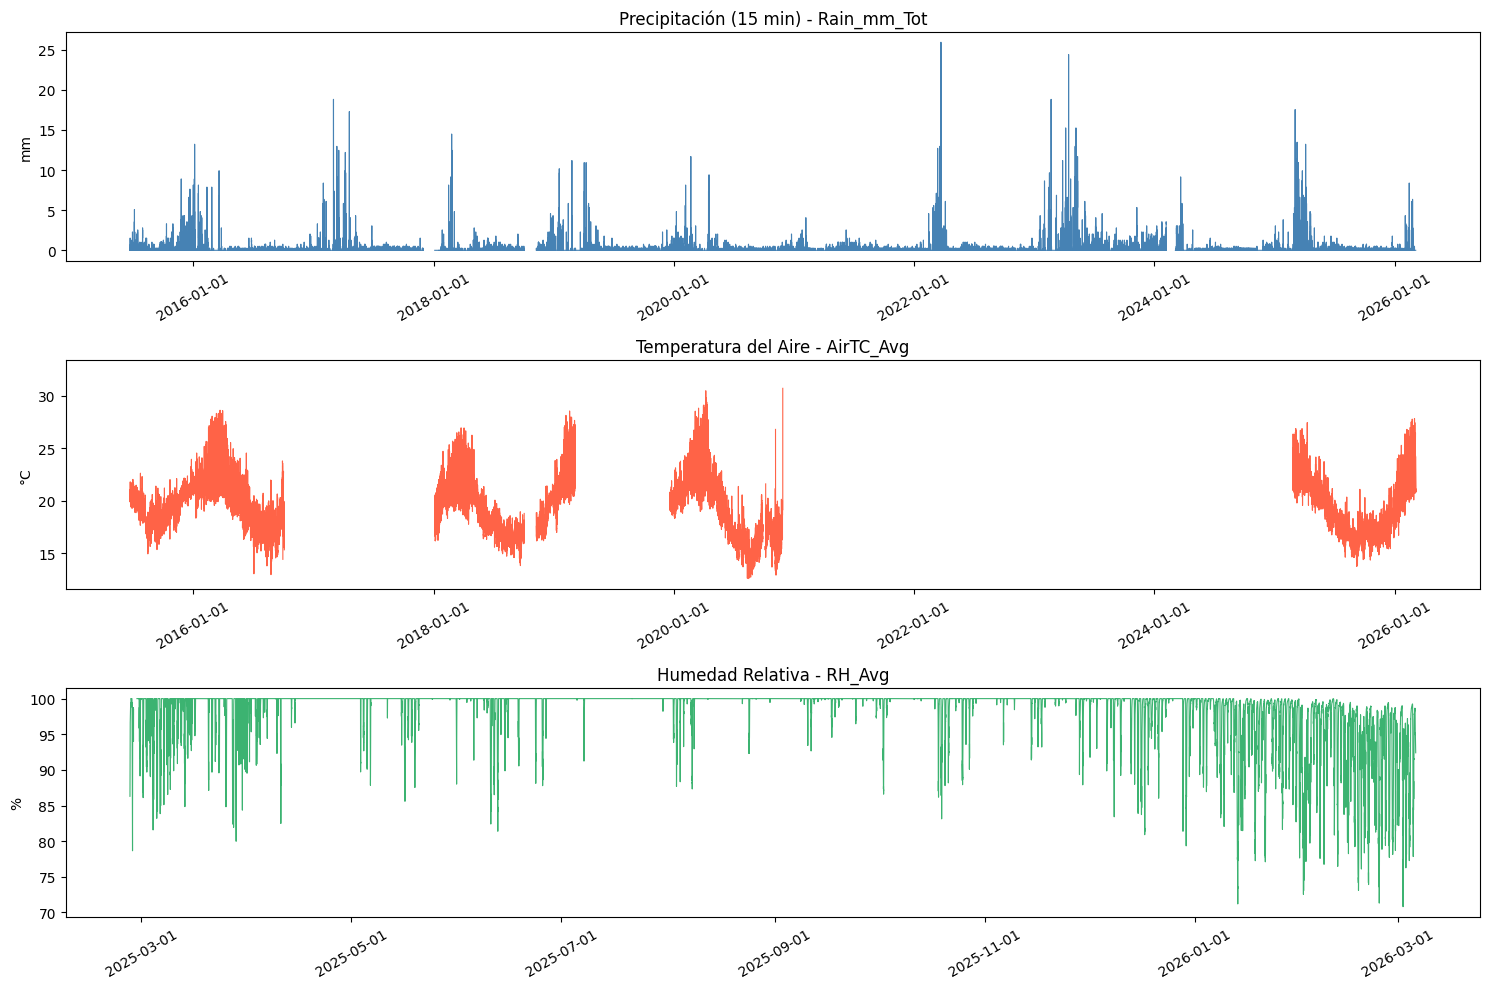

In [12]:
# Visualización de la serie de precipitación a 15 min
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(df.index, df['Rain_mm_Tot'], color='steelblue', linewidth=0.8)
axes[0].set_title('Precipitación (15 min) - Rain_mm_Tot')
axes[0].set_ylabel('mm')

axes[1].plot(df.index, df['AirTC_Avg'], color='tomato', linewidth=0.8)
axes[1].set_title('Temperatura del Aire - AirTC_Avg')
axes[1].set_ylabel('°C')

axes[2].plot(df.index, df['RH_Avg'], color='mediumseagreen', linewidth=0.8)
axes[2].set_title('Humedad Relativa - RH_Avg')
axes[2].set_ylabel('%')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('series_15min.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Resampleo de 15 min → 1 Hora

> **Regla:**  
> - `Rain_mm_Tot` → **suma** (acumulación de lluvia en la hora)  
> - Resto de variables → **media** (promedio de los 4 registros)

In [13]:
# Columna objetivo de precipitación
RAIN_COL = 'Rain_mm_Tot'

# Separar columnas por tipo de agregación
other_cols = [c for c in df.columns if c != RAIN_COL]

# Resampleo
df_mean = df[other_cols].resample('1H').mean()
df_rain = df[[RAIN_COL]].resample('1H').sum()

df_hourly = pd.concat([df_mean, df_rain], axis=1)

print(f'Shape 15 min : {df.shape}')
print(f'Shape 1 hora : {df_hourly.shape}')
print(f'\nPrimeros registros horarios:')
df_hourly.head(6)

Shape 15 min : (375325, 53)
Shape 1 hora : (93832, 53)

Primeros registros horarios:


,BattV_Avg,PTemp_C_Avg,LWmV_Avg,AirTC_Avg,RH_Max,SlrkW_Avg,SlrMJ_Tot,NR_Wm2_Avg,VW,PA_uS,...,PA_uS_3_Max,PA_uS_3_Min,NR_Wm2_Max,NR_Wm2_Min,CNR_Wm2_Max,CNR_Wm2_Min,CNR_Wm2_Avg,RECORD,WindDir_Avg,Rain_mm_Tot
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2015-06-22 15:00:00,13.270000,21.510833,312.791667,20.939167,99.975,0.121000,0.070351,100.391667,0.548083,34.465833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000
2015-06-22 16:00:00,13.078333,21.124167,365.158333,20.808333,100.000,0.034417,0.031076,24.483583,0.546333,34.426667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000
2015-06-22 17:00:00,12.906667,20.977500,429.225000,20.738333,100.000,0.009750,0.008765,5.598917,0.545500,34.405833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.254
2015-06-22 18:00:00,12.844167,20.749167,448.725000,20.454167,100.000,0.000417,0.000390,-2.420417,0.544667,34.376667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000
2015-06-22 19:00:00,12.818333,20.620833,474.333333,20.415833,100.000,0.000000,0.000005,-2.716083,0.543583,34.365833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000
2015-06-22 20:00:00,12.802500,20.598333,494.366667,20.468333,100.000,0.000000,0.000000,-1.901917,0.543000,34.345000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000


In [14]:
# Verificar suma de lluvia: total 15min vs total horario
total_15min = df[RAIN_COL].sum()
total_1h    = df_hourly[RAIN_COL].sum()
print(f'Total lluvia (15 min): {total_15min:.4f} mm')
print(f'Total lluvia (1 hora): {total_1h:.4f} mm')
print(f'Diferencia           : {abs(total_15min - total_1h):.6f} mm  ✅')

Total lluvia (15 min): 16737.3980 mm
Total lluvia (1 hora): 16737.3980 mm
Diferencia           : 0.000000 mm  ✅


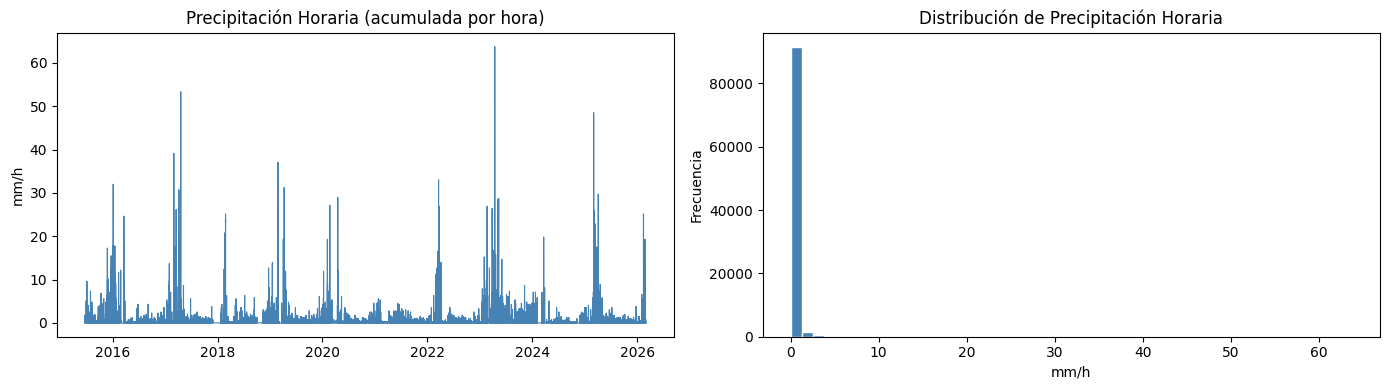

Horas con lluvia > 0 : 19591 / 93832


In [15]:
# Distribución de lluvia horaria
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_hourly.index, df_hourly[RAIN_COL], color='steelblue', linewidth=0.8)
axes[0].set_title('Precipitación Horaria (acumulada por hora)')
axes[0].set_ylabel('mm/h')

axes[1].hist(df_hourly[RAIN_COL], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de Precipitación Horaria')
axes[1].set_xlabel('mm/h')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('distribucion_lluvia_1h.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Horas con lluvia > 0 : {(df_hourly[RAIN_COL] > 0).sum()} / {len(df_hourly)}')

## 5. Preprocesamiento

In [16]:
# ============================================================
# SELECCIÓN DE FEATURES
# Ajusta esta lista según las columnas disponibles en tu CSV
# ============================================================
FEATURES = [
    'AirTC_Avg',    # Temperatura del aire
    'RH_Avg',       # Humedad relativa promedio
    'RH_Max',       # Humedad relativa máxima
    'SlrkW_Avg',    # Radiación solar (kW)
    'NR_Wm2_Avg',   # Radiación neta
    'WS_ms_Avg',    # Velocidad del viento
    'LWmV_Avg',     # Leaf wetness
    RAIN_COL        # Target: precipitación
]

# Filtrar solo columnas disponibles
FEATURES = [f for f in FEATURES if f in df_hourly.columns]
print(f'Features utilizadas: {FEATURES}')

data = df_hourly[FEATURES].copy()

Features utilizadas: ['AirTC_Avg', 'RH_Avg', 'RH_Max', 'SlrkW_Avg', 'NR_Wm2_Avg', 'WS_ms_Avg', 'LWmV_Avg', 'Rain_mm_Tot']


In [17]:
# Interpolación lineal para NaN (máx 3 horas consecutivas)
data = data.interpolate(method='linear', limit=3)
data = data.dropna()

print(f'Shape tras limpieza: {data.shape}')
print(f'NaN restantes: {data.isnull().sum().sum()}')

Shape tras limpieza: (0, 8)
NaN restantes: 0


In [42]:
# Agregar features temporales cíclicas
data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
data['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
data['month_sin'] = np.sin(2 * np.pi * data.index.month / 12)
data['month_cos'] = np.cos(2 * np.pi * data.index.month / 12)

# Lags de lluvia (últimas 3 horas)
data['Rain_lag1'] = data['Rain_mm_Tot'].shift(1)
data['Rain_lag2'] = data['Rain_mm_Tot'].shift(2)
data['Rain_lag3'] = data['Rain_mm_Tot'].shift(3)

data = data.dropna()

print(f'Shape con nuevas features: {data.shape}')
print(f'Features: {data.columns.tolist()}')

Shape con nuevas features: (84155, 11)
Features: ['SlrkW_Avg', 'NR_Wm2_Avg', 'WS_ms_Avg', 'Rain_mm_Tot', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Rain_lag1', 'Rain_lag2', 'Rain_lag3']


In [43]:
# Ver % de NaN por columna
nan_pct = (df_hourly[FEATURES].isnull().sum() / len(df_hourly) * 100).round(1)
print("% NaN por columna:")
print(nan_pct)

% NaN por columna:
SlrkW_Avg      3.3
NR_Wm2_Avg     9.8
WS_ms_Avg      3.4
Rain_mm_Tot    0.0
dtype: float64


In [37]:
# Solo columnas con menos del 15% de NaN
FEATURES = ['SlrkW_Avg', 'NR_Wm2_Avg', 'WS_ms_Avg', 'Rain_mm_Tot']

print(f'Features finales: {FEATURES}')

data = df_hourly[FEATURES].copy()

# Interpolación hasta 6 horas consecutivas de huecos
data = data.interpolate(method='linear', limit=6)

# Eliminar filas con NaN residuales (bordes de la serie)
data = data.dropna()

print(f'Shape final: {data.shape}')
print(f'NaN restantes: {data.isnull().sum().sum()}')
print(data.head())

Features finales: ['SlrkW_Avg', 'NR_Wm2_Avg', 'WS_ms_Avg', 'Rain_mm_Tot']
Shape final: (84158, 4)
NaN restantes: 0
                     SlrkW_Avg  NR_Wm2_Avg  WS_ms_Avg  Rain_mm_Tot
TIMESTAMP                                                         
2015-06-22 15:00:00   0.121000  100.391667   4.166500        0.000
2015-06-22 16:00:00   0.034417   24.483583   4.878917        0.000
2015-06-22 17:00:00   0.009750    5.598917   5.122917        0.254
2015-06-22 18:00:00   0.000417   -2.420417   4.782417        0.000
2015-06-22 19:00:00   0.000000   -2.716083   4.182833        0.000


In [44]:
rain_idx   = list(data.columns).index('Rain_mm_Tot')
n_features = data.shape[1]

print(f'rain_idx   : {rain_idx}')    # debe ser 3
print(f'n_features : {n_features}')  # debe ser 4

rain_idx   : 3
n_features : 11


In [54]:
FEATURES = [
    'SlrkW_Avg',    # 3.3%  - Radiación solar
    'SlrMJ_Tot',    # 3.3%  - Energía solar acumulada
    'WS_ms_Avg',    # 3.4%  - Velocidad viento
    'NR_Wm2_Avg',   # 9.8%  - Radiación neta
    'VW',           # 2.8%  - Volumetric Water Content (humedad suelo)
    'VW_2',         # 2.7%  - Humedad suelo sensor 2
    'VW_3',         # 2.7%  - Humedad suelo sensor 3
    'WindDir',      # 16.8% - Dirección del viento
    'Rain_mm_Tot'   # 0.0%  - Target
]

data = df_hourly[FEATURES].copy()
data = data.interpolate(method='linear', limit=6)
data = data.dropna()

# Features temporales cíclicas
data['hour_sin']  = np.sin(2 * np.pi * data.index.hour / 24)
data['hour_cos']  = np.cos(2 * np.pi * data.index.hour / 24)
data['month_sin'] = np.sin(2 * np.pi * data.index.month / 12)
data['month_cos'] = np.cos(2 * np.pi * data.index.month / 12)

# Lags de lluvia
data['Rain_lag1'] = data['Rain_mm_Tot'].shift(1)
data['Rain_lag2'] = data['Rain_mm_Tot'].shift(2)
data['Rain_lag3'] = data['Rain_mm_Tot'].shift(3)

data = data.dropna()

print(f'Shape final: {data.shape}')
print(f'Features ({len(data.columns)}): {data.columns.tolist()}')

Shape final: (71302, 16)
Features (16): ['SlrkW_Avg', 'SlrMJ_Tot', 'WS_ms_Avg', 'NR_Wm2_Avg', 'VW', 'VW_2', 'VW_3', 'WindDir', 'Rain_mm_Tot', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Rain_lag1', 'Rain_lag2', 'Rain_lag3']


In [55]:
print(data.columns.tolist())
print(data.shape)

['SlrkW_Avg', 'SlrMJ_Tot', 'WS_ms_Avg', 'NR_Wm2_Avg', 'VW', 'VW_2', 'VW_3', 'WindDir', 'Rain_mm_Tot', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Rain_lag1', 'Rain_lag2', 'Rain_lag3']
(71302, 16)


In [56]:
print("NaN por columna en df_hourly:")
print(df_hourly[FEATURES].isnull().sum())
print(f"\nTotal filas df_hourly: {len(df_hourly)}")

NaN por columna en df_hourly:
SlrkW_Avg       3118
SlrMJ_Tot       3097
WS_ms_Avg       3207
NR_Wm2_Avg      9202
VW              2596
VW_2            2566
VW_3            2566
WindDir        15756
Rain_mm_Tot        0
dtype: int64

Total filas df_hourly: 93832


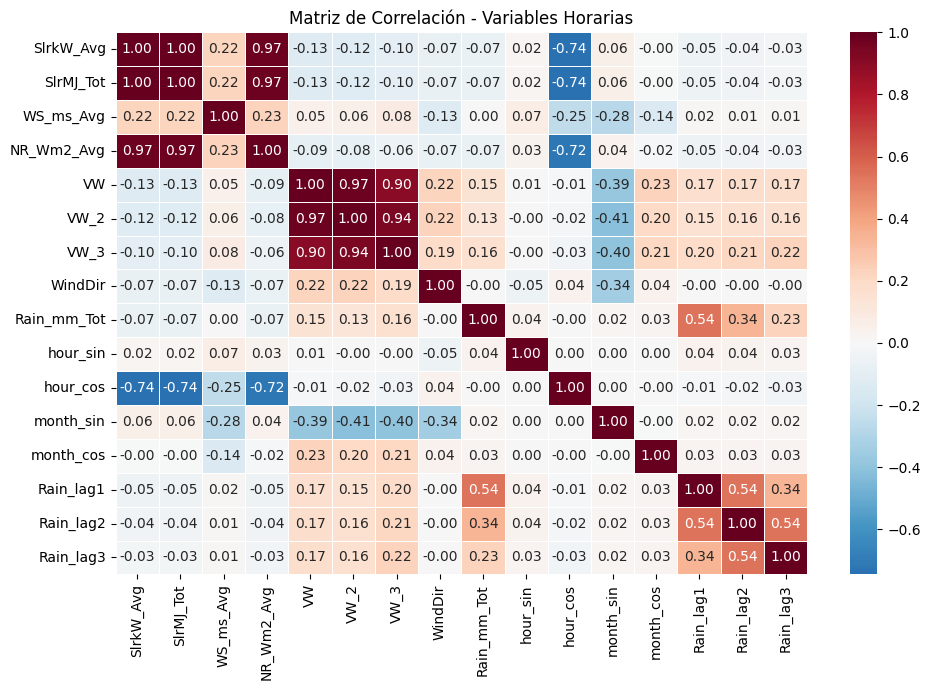

In [57]:
plt.figure(figsize=(10, 7))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de Correlación - Variables Horarias')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Funciones Auxiliares para los 3 Modelos GRU

In [58]:
def create_sequences(data_scaled, target_col_idx, look_back, horizon):
    """
    Crea ventanas deslizantes.
    
    Parameters
    ----------
    data_scaled   : np.array  - datos normalizados
    target_col_idx: int       - índice de la columna objetivo (Rain)
    look_back     : int       - pasos temporales de entrada
    horizon       : int       - pasos a predecir (1, 3 o 6 horas)
    
    Returns
    -------
    X : (samples, look_back, features)
    y : (samples, horizon)  — predicción multi-step
    """
    X, y = [], []
    n = len(data_scaled)
    for i in range(n - look_back - horizon + 1):
        X.append(data_scaled[i : i + look_back, :])           # todas las features
        y.append(data_scaled[i + look_back : i + look_back + horizon, target_col_idx])  # solo lluvia
    return np.array(X), np.array(y)


def build_gru_model(look_back, n_features, horizon,
                    units1=64, units2=32, dropout=0.2, lr=1e-3):
    """Construye el modelo GRU para predicción multi-step."""
    model = Sequential([
        GRU(units1, return_sequences=True,
            input_shape=(look_back, n_features)),
        Dropout(dropout),
        GRU(units2, return_sequences=False),
        Dropout(dropout),
        Dense(horizon)          # salida: 'horizon' pasos
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model


def inverse_rain(y_scaled, scaler, target_col_idx, n_features):
    """Desnormaliza solo la columna de lluvia."""
    dummy = np.zeros((y_scaled.shape[0] * y_scaled.shape[1], n_features))
    flat  = y_scaled.flatten()
    dummy[:, target_col_idx] = flat
    return scaler.inverse_transform(dummy)[:, target_col_idx].reshape(y_scaled.shape)


def evaluate_model(y_true, y_pred, horizon_label):
    """Calcula y muestra métricas de evaluación."""
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    rmse = np.sqrt(mean_squared_error(y_true_f, y_pred_f))
    mae  = mean_absolute_error(y_true_f, y_pred_f)
    r2   = r2_score(y_true_f, y_pred_f)
    print(f'\n📊 Métricas - Horizonte {horizon_label}')
    print(f'   RMSE : {rmse:.4f} mm')
    print(f'   MAE  : {mae:.4f} mm')
    print(f'   R²   : {r2:.4f}')
    return {'horizon': horizon_label, 'RMSE': rmse, 'MAE': mae, 'R2': r2}


print('✅ Funciones definidas correctamente')

✅ Funciones definidas correctamente


## 7. Normalización y División de Datos

In [59]:
# ============================================================
# PARÁMETROS GLOBALES - Ajusta si es necesario
# ============================================================
LOOK_BACK  = 24    # Ventana de entrada: 24 horas previas
TRAIN_FRAC = 0.70  # 70% train, 15% val, 15% test
VAL_FRAC   = 0.15
EPOCHS     = 100
BATCH_SIZE = 32
PATIENCE   = 15

# Índice de la columna Rain en el array
rain_idx = list(data.columns).index(RAIN_COL)
n_features = data.shape[1]
print(f'Índice de Rain: {rain_idx}  |  Num. features: {n_features}')

# Normalización (fit solo en train para evitar data leakage)
n_total = len(data)
n_train = int(n_total * TRAIN_FRAC)
n_val   = int(n_total * VAL_FRAC)

scaler = MinMaxScaler(feature_range=(0, 1))
data_np = data.values.astype(np.float32)

scaler.fit(data_np[:n_train])
data_scaled = scaler.transform(data_np)

print(f'\nTamaño total  : {n_total}')
print(f'Train         : {n_train}')
print(f'Validation    : {n_val}')
print(f'Test          : {n_total - n_train - n_val}')

Índice de Rain: 8  |  Num. features: 16

Tamaño total  : 71302
Train         : 49911
Validation    : 10695
Test          : 10696


---
## 8. MODELO 1 — Predicción a 1 Hora

In [60]:
HORIZON_1H = 1

X_1h, y_1h = create_sequences(data_scaled, rain_idx, LOOK_BACK, HORIZON_1H)

# División manteniendo orden temporal
X_tr1, y_tr1 = X_1h[:n_train], y_1h[:n_train]
X_vl1, y_vl1 = X_1h[n_train:n_train+n_val], y_1h[n_train:n_train+n_val]
X_ts1, y_ts1 = X_1h[n_train+n_val:], y_1h[n_train+n_val:]

print(f'Train: {X_tr1.shape}  |  Val: {X_vl1.shape}  |  Test: {X_ts1.shape}')

Train: (49911, 24, 16)  |  Val: (10695, 24, 16)  |  Test: (10672, 24, 16)


In [61]:
model_1h = build_gru_model(LOOK_BACK, n_features, HORIZON_1H)
model_1h.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_8 (GRU)                     │ (None, 24, 64)         │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,185 (98.38 KB)

 Trainable params: 25,185 (98.38 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
callbacks_1h = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

history_1h = model_1h.fit(
    X_tr1, y_tr1,
    validation_data=(X_vl1, y_vl1),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_1h,
    verbose=1
)

Epoch 1/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 7.7559e-04 - mae: 0.0149 - val_loss: 6.4852e-04 - val_mae: 0.0059 - learning_rate: 0.0010
Epoch 2/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 2.8244e-04 - mae: 0.0073 - val_loss: 5.9787e-04 - val_mae: 0.0062 - learning_rate: 0.0010
Epoch 3/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - loss: 2.5162e-04 - mae: 0.0061 - val_loss: 5.4981e-04 - val_mae: 0.0054 - learning_rate: 0.0010
Epoch 4/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - loss: 2.3244e-04 - mae: 0.0054 - val_loss: 5.1807e-04 - val_mae: 0.0047 - learning_rate: 0.0010
Epoch 5/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - loss: 2.2229e-04 - mae: 0.0052 - val_loss: 4.7906e-04 - val_mae: 0.0047 - learning_rate: 0.0010
Epoch 6/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - loss: 2.1645e-04 - mae: 0.0050 - val_loss: 4.8342e-04 - val_mae: 0.0043 - learning_rate: 0.0010
Epoch 7/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 2.206

In [63]:
pred_1h_scaled = model_1h.predict(X_ts1)
pred_1h = np.clip(inverse_rain(pred_1h_scaled, scaler, rain_idx, n_features), 0, None)
true_1h = inverse_rain(y_ts1, scaler, rain_idx, n_features)

# Métricas globales
metrics_1h = evaluate_model(true_1h, pred_1h, '1 Hora')

# Métricas solo en horas con lluvia real
mask = true_1h.flatten() > 0
rmse_rain = np.sqrt(mean_squared_error(true_1h.flatten()[mask], pred_1h.flatten()[mask]))
mae_rain  = mean_absolute_error(true_1h.flatten()[mask], pred_1h.flatten()[mask])

print(f'\n🌧️  Métricas SOLO en horas con lluvia ({mask.sum()} muestras):')
print(f'   RMSE : {rmse_rain:.4f} mm')
print(f'   MAE  : {mae_rain:.4f} mm')

# Qué porcentaje del tiempo predice 0
pct_zeros = (pred_1h.flatten() == 0).sum() / len(pred_1h.flatten()) * 100
print(f'\n⚠️  % predicciones = 0: {pct_zeros:.1f}%')

334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

📊 Métricas - Horizonte 1 Hora
   RMSE : 0.5735 mm
   MAE  : 0.2295 mm
   R²   : 0.2537

🌧️  Métricas SOLO en horas con lluvia (2418 muestras):
   RMSE : 1.1353 mm
   MAE  : 0.5780 mm

⚠️  % predicciones = 0: 5.8%


In [53]:
# Ver TODAS las columnas con menos del 50% de NaN
nan_pct_all = (df_hourly.isnull().sum() / len(df_hourly) * 100).round(1)
columnas_utiles = nan_pct_all[nan_pct_all < 50].sort_values()
print("Columnas con menos del 50% de NaN:")
print(columnas_utiles.to_string())

Columnas con menos del 50% de NaN:
Rain_mm_Tot     0.0
VW_2            2.7
PA_uS_2         2.7
PA_uS_3         2.7
VW_3            2.7
VW              2.8
PA_uS           2.8
SlrMJ_Tot       3.3
SlrkW_Avg       3.3
WS_ms_Avg       3.4
NR_Wm2_Avg      9.8
BattV_Avg      12.3
PTemp_C_Avg    12.3
WindDir        16.8


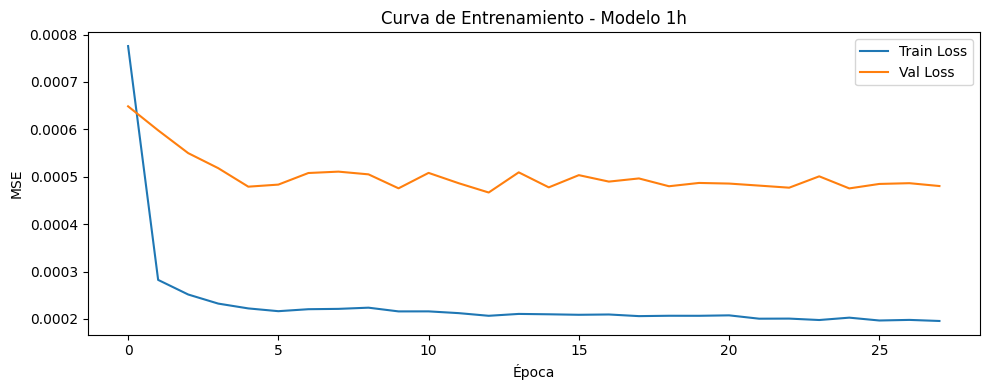

In [64]:
# Curva de pérdida
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_1h.history['loss'],     label='Train Loss')
ax.plot(history_1h.history['val_loss'], label='Val Loss')
ax.set_title('Curva de Entrenamiento - Modelo 1h')
ax.set_xlabel('Época'); ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout()
plt.savefig('loss_1h.png', dpi=120, bbox_inches='tight')
plt.show()

In [65]:
# Ver distribución de lluvia en cada split
print("=== Distribución de lluvia por split ===")
print(f"Train  - Media: {true_1h[:len(X_tr1)].mean():.4f}  | % lluvia: {(data['Rain_mm_Tot'].values[:n_train] > 0).mean()*100:.1f}%")
print(f"Val    - Media: {data['Rain_mm_Tot'].values[n_train:n_train+n_val].mean():.4f} | % lluvia: {(data['Rain_mm_Tot'].values[n_train:n_train+n_val] > 0).mean()*100:.1f}%")
print(f"Test   - Media: {data['Rain_mm_Tot'].values[n_train+n_val:].mean():.4f} | % lluvia: {(data['Rain_mm_Tot'].values[n_train+n_val:] > 0).mean()*100:.1f}%")

# Ver qué período cubre cada split
n_total = len(data)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)
print(f"\nTrain : {data.index[0]} → {data.index[n_train]}")
print(f"Val   : {data.index[n_train]} → {data.index[n_train+n_val]}")
print(f"Test  : {data.index[n_train+n_val]} → {data.index[-1]}")

=== Distribución de lluvia por split ===
Train  - Media: 0.1994  | % lluvia: 21.8%
Val    - Media: 0.2213 | % lluvia: 20.2%
Test   - Media: 0.1990 | % lluvia: 22.6%

Train : 2015-06-22 18:00:00 → 2022-03-01 12:00:00
Val   : 2022-03-01 12:00:00 → 2023-05-27 21:00:00
Test  : 2023-05-27 21:00:00 → 2024-09-12 05:00:00


In [66]:
# Predicción y desnormalización
pred_1h_scaled = model_1h.predict(X_ts1)
pred_1h = inverse_rain(pred_1h_scaled, scaler, rain_idx, n_features)
true_1h = inverse_rain(y_ts1,          scaler, rain_idx, n_features)

# Clip negativos (lluvia no puede ser negativa)
pred_1h = np.clip(pred_1h, 0, None)

metrics_1h = evaluate_model(true_1h, pred_1h, '1 Hora')

334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

📊 Métricas - Horizonte 1 Hora
   RMSE : 0.5735 mm
   MAE  : 0.2295 mm
   R²   : 0.2537


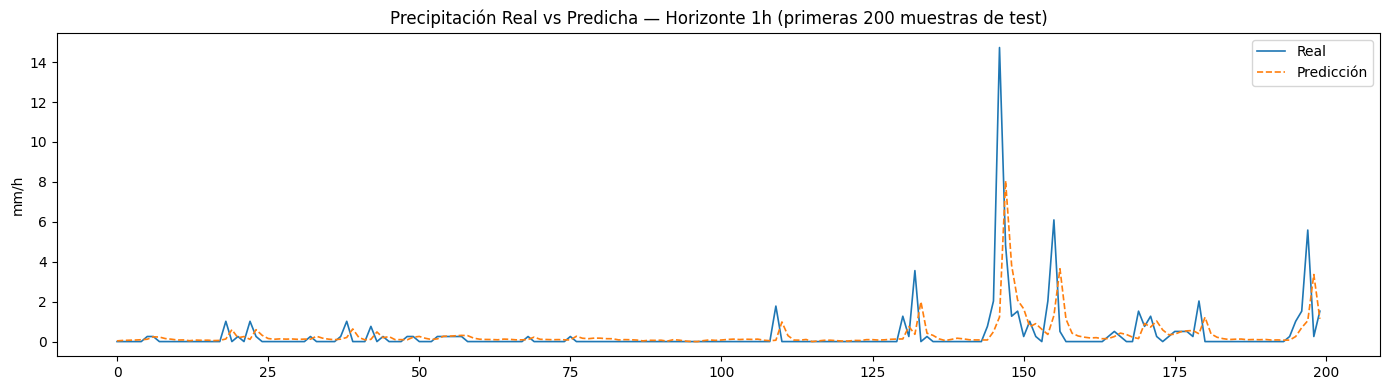

In [67]:
# Visualización predicción vs real
n_show = min(200, len(true_1h))
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(true_1h[:n_show, 0],  label='Real',       linewidth=1.2)
ax.plot(pred_1h[:n_show, 0],  label='Predicción', linewidth=1.2, linestyle='--')
ax.set_title(f'Precipitación Real vs Predicha — Horizonte 1h (primeras {n_show} muestras de test)')
ax.set_ylabel('mm/h'); ax.legend()
plt.tight_layout()
plt.savefig('pred_vs_real_1h.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. MODELO 2 — Predicción a 3 Horas

In [68]:
HORIZON_3H = 3

X_3h, y_3h = create_sequences(data_scaled, rain_idx, LOOK_BACK, HORIZON_3H)

X_tr3, y_tr3 = X_3h[:n_train], y_3h[:n_train]
X_vl3, y_vl3 = X_3h[n_train:n_train+n_val], y_3h[n_train:n_train+n_val]
X_ts3, y_ts3 = X_3h[n_train+n_val:], y_3h[n_train+n_val:]

print(f'Train: {X_tr3.shape}  |  Val: {X_vl3.shape}  |  Test: {X_ts3.shape}')

Train: (49911, 24, 16)  |  Val: (10695, 24, 16)  |  Test: (10670, 24, 16)


In [69]:
model_3h = build_gru_model(LOOK_BACK, n_features, HORIZON_3H,
                            units1=64, units2=32, dropout=0.2)

callbacks_3h = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

history_3h = model_3h.fit(
    X_tr3, y_tr3,
    validation_data=(X_vl3, y_vl3),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_3h,
    verbose=1
)

Epoch 1/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 6.9016e-04 - mae: 0.0138 - val_loss: 6.8289e-04 - val_mae: 0.0061 - learning_rate: 0.0010
Epoch 2/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 2.8364e-04 - mae: 0.0069 - val_loss: 6.6577e-04 - val_mae: 0.0056 - learning_rate: 0.0010
Epoch 3/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 2.6354e-04 - mae: 0.0059 - val_loss: 6.5822e-04 - val_mae: 0.0057 - learning_rate: 0.0010
Epoch 4/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 2.5064e-04 - mae: 0.0054 - val_loss: 6.4587e-04 - val_mae: 0.0104 - learning_rate: 0.0010
Epoch 5/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 2.4903e-04 - mae: 0.0052 - val_loss: 6.1200e-04 - val_mae: 0.0063 - learning_rate: 0.0010
Epoch 6/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 2.4609e-04 - mae: 0.0051 - val_loss: 6.1243e-04 - val_mae: 0.0050 - learning_rate: 0.0010
Epoch 7/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 2.447

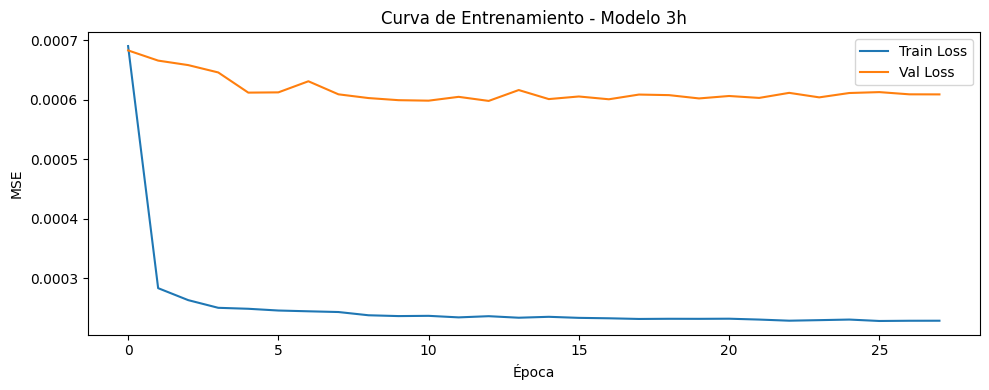

In [70]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_3h.history['loss'],     label='Train Loss')
ax.plot(history_3h.history['val_loss'], label='Val Loss')
ax.set_title('Curva de Entrenamiento - Modelo 3h')
ax.set_xlabel('Época'); ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout()
plt.savefig('loss_3h.png', dpi=120, bbox_inches='tight')
plt.show()

In [71]:
pred_3h_scaled = model_3h.predict(X_ts3)
pred_3h = np.clip(inverse_rain(pred_3h_scaled, scaler, rain_idx, n_features), 0, None)
true_3h = inverse_rain(y_ts3, scaler, rain_idx, n_features)

metrics_3h = evaluate_model(true_3h, pred_3h, '3 Horas')

334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

📊 Métricas - Horizonte 3 Horas
   RMSE : 0.6043 mm
   MAE  : 0.2486 mm
   R²   : 0.1714


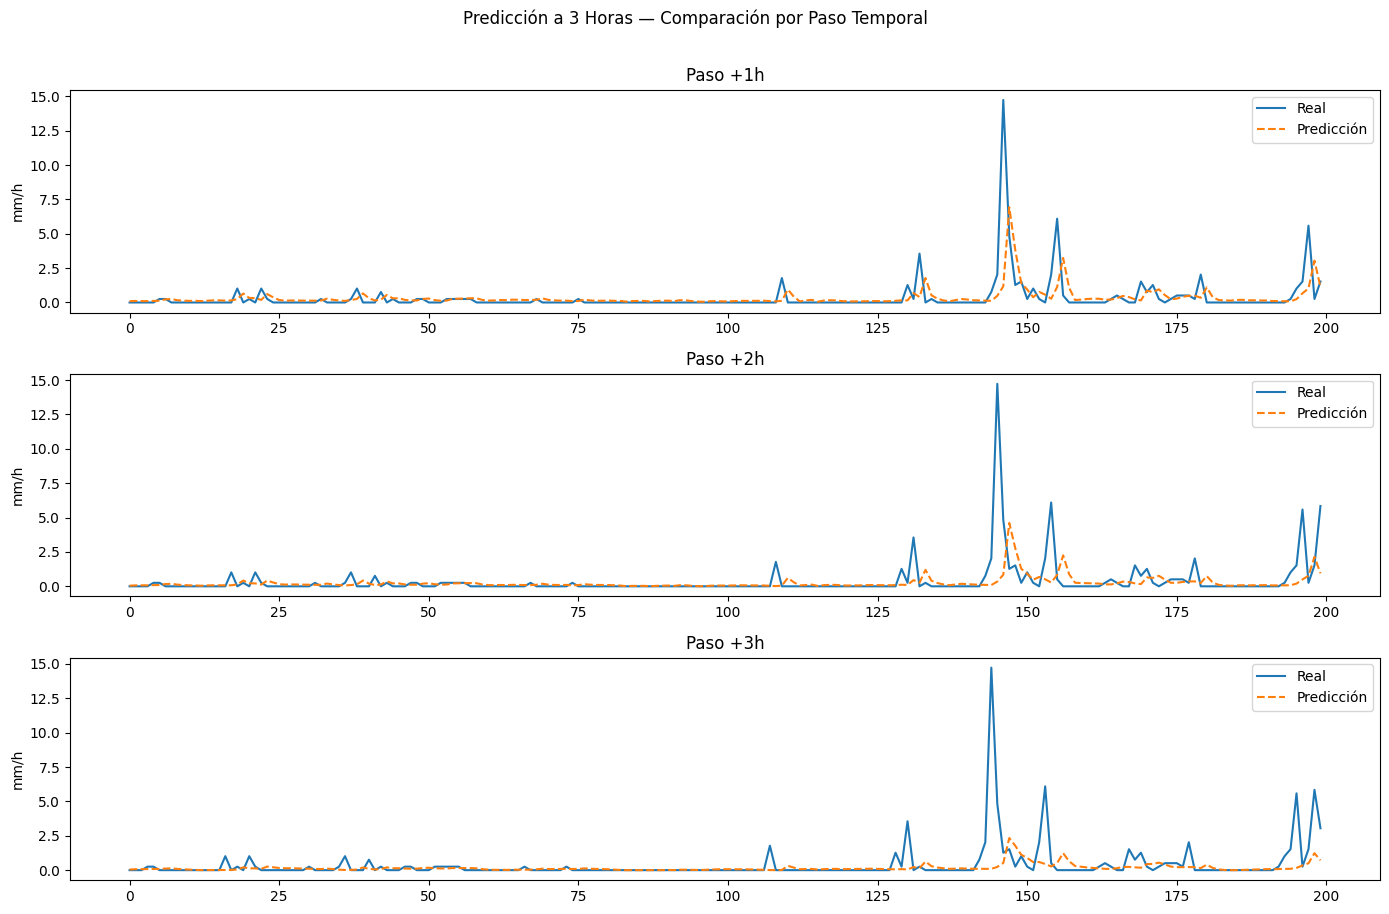

In [72]:
# Comparar cada paso del horizonte
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for i, ax in enumerate(axes):
    n_show = min(200, len(true_3h))
    ax.plot(true_3h[:n_show, i],  label='Real')
    ax.plot(pred_3h[:n_show, i],  label='Predicción', linestyle='--')
    ax.set_title(f'Paso +{i+1}h')
    ax.set_ylabel('mm/h'); ax.legend()
plt.suptitle('Predicción a 3 Horas — Comparación por Paso Temporal', y=1.01)
plt.tight_layout()
plt.savefig('pred_vs_real_3h.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 10. MODELO 3 — Predicción a 6 Horas

In [73]:
HORIZON_6H = 6

X_6h, y_6h = create_sequences(data_scaled, rain_idx, LOOK_BACK, HORIZON_6H)

X_tr6, y_tr6 = X_6h[:n_train], y_6h[:n_train]
X_vl6, y_vl6 = X_6h[n_train:n_train+n_val], y_6h[n_train:n_train+n_val]
X_ts6, y_ts6 = X_6h[n_train+n_val:], y_6h[n_train+n_val:]

print(f'Train: {X_tr6.shape}  |  Val: {X_vl6.shape}  |  Test: {X_ts6.shape}')

Train: (49911, 24, 16)  |  Val: (10695, 24, 16)  |  Test: (10667, 24, 16)


In [74]:
# Para horizonte más largo, arquitectura ligeramente más profunda
model_6h = build_gru_model(LOOK_BACK, n_features, HORIZON_6H,
                            units1=128, units2=64, dropout=0.25)

callbacks_6h = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

history_6h = model_6h.fit(
    X_tr6, y_tr6,
    validation_data=(X_vl6, y_vl6),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_6h,
    verbose=1
)

Epoch 1/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - loss: 5.8934e-04 - mae: 0.0124 - val_loss: 6.9220e-04 - val_mae: 0.0057 - learning_rate: 0.0010
Epoch 2/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - loss: 2.8693e-04 - mae: 0.0067 - val_loss: 6.7943e-04 - val_mae: 0.0064 - learning_rate: 0.0010
Epoch 3/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - loss: 2.7044e-04 - mae: 0.0059 - val_loss: 6.6986e-04 - val_mae: 0.0060 - learning_rate: 0.0010
Epoch 4/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - loss: 2.6294e-04 - mae: 0.0054 - val_loss: 6.6783e-04 - val_mae: 0.0050 - learning_rate: 0.0010
Epoch 5/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - loss: 2.5880e-04 - mae: 0.0053 - val_loss: 6.6872e-04 - val_mae: 0.0054 - learning_rate: 0.0010
Epoch 6/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 2.5678e-04 - mae: 0.0052 - val_loss: 6.6839e-04 - val_mae: 0.0050 - learning_rate: 0.0010
Epoch 7/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 2.565

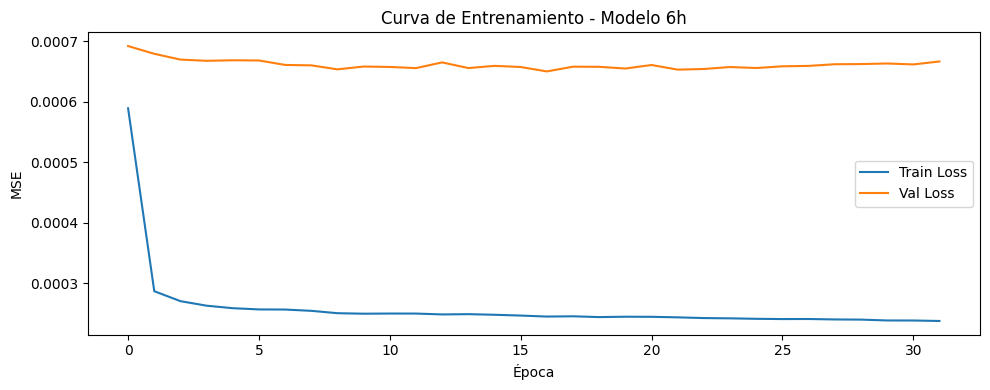

In [75]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_6h.history['loss'],     label='Train Loss')
ax.plot(history_6h.history['val_loss'], label='Val Loss')
ax.set_title('Curva de Entrenamiento - Modelo 6h')
ax.set_xlabel('Época'); ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout()
plt.savefig('loss_6h.png', dpi=120, bbox_inches='tight')
plt.show()

In [76]:
pred_6h_scaled = model_6h.predict(X_ts6)
pred_6h = np.clip(inverse_rain(pred_6h_scaled, scaler, rain_idx, n_features), 0, None)
true_6h = inverse_rain(y_ts6, scaler, rain_idx, n_features)

metrics_6h = evaluate_model(true_6h, pred_6h, '6 Horas')

334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

📊 Métricas - Horizonte 6 Horas
   RMSE : 0.6242 mm
   MAE  : 0.2479 mm
   R²   : 0.1162


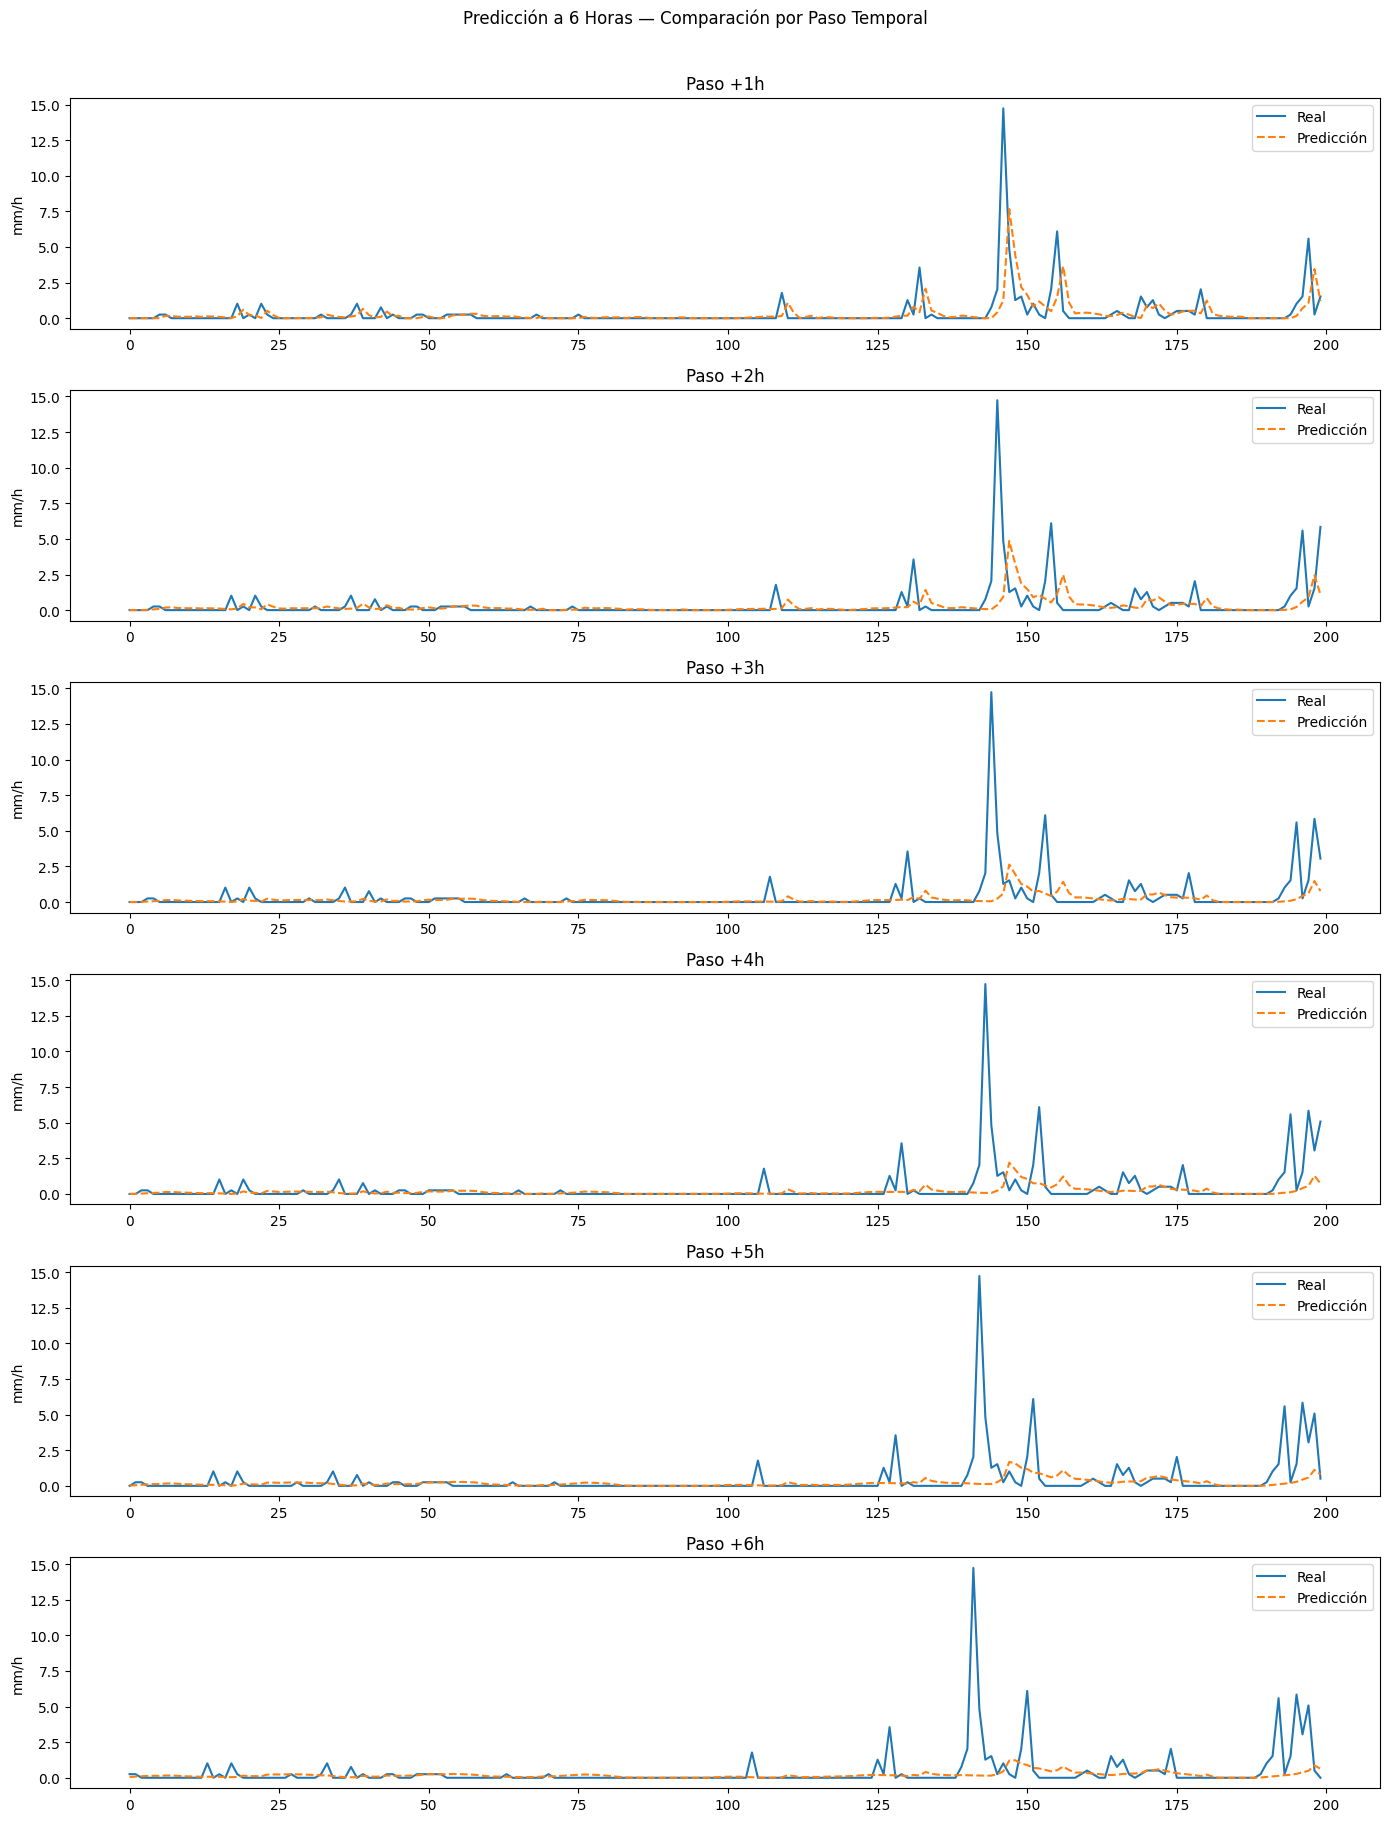

In [77]:
fig, axes = plt.subplots(6, 1, figsize=(14, 18))
for i, ax in enumerate(axes):
    n_show = min(200, len(true_6h))
    ax.plot(true_6h[:n_show, i],  label='Real')
    ax.plot(pred_6h[:n_show, i],  label='Predicción', linestyle='--')
    ax.set_title(f'Paso +{i+1}h')
    ax.set_ylabel('mm/h'); ax.legend()
plt.suptitle('Predicción a 6 Horas — Comparación por Paso Temporal', y=1.01)
plt.tight_layout()
plt.savefig('pred_vs_real_6h.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 11. Comparación Final de Modelos

In [78]:
results = pd.DataFrame([metrics_1h, metrics_3h, metrics_6h])
results = results.set_index('horizon')
print('\n=== RESUMEN COMPARATIVO ===')
print(results.to_string())
results


=== RESUMEN COMPARATIVO ===
             RMSE       MAE        R2
horizon                              
1 Hora   0.573511  0.229524  0.253698
3 Horas  0.604340  0.248606  0.171357
6 Horas  0.624195  0.247949  0.116210


,RMSE,MAE,R2
horizon,,,
1 Hora,0.573511,0.229524,0.253698
3 Horas,0.604340,0.248606,0.171357
6 Horas,0.624195,0.247949,0.116210


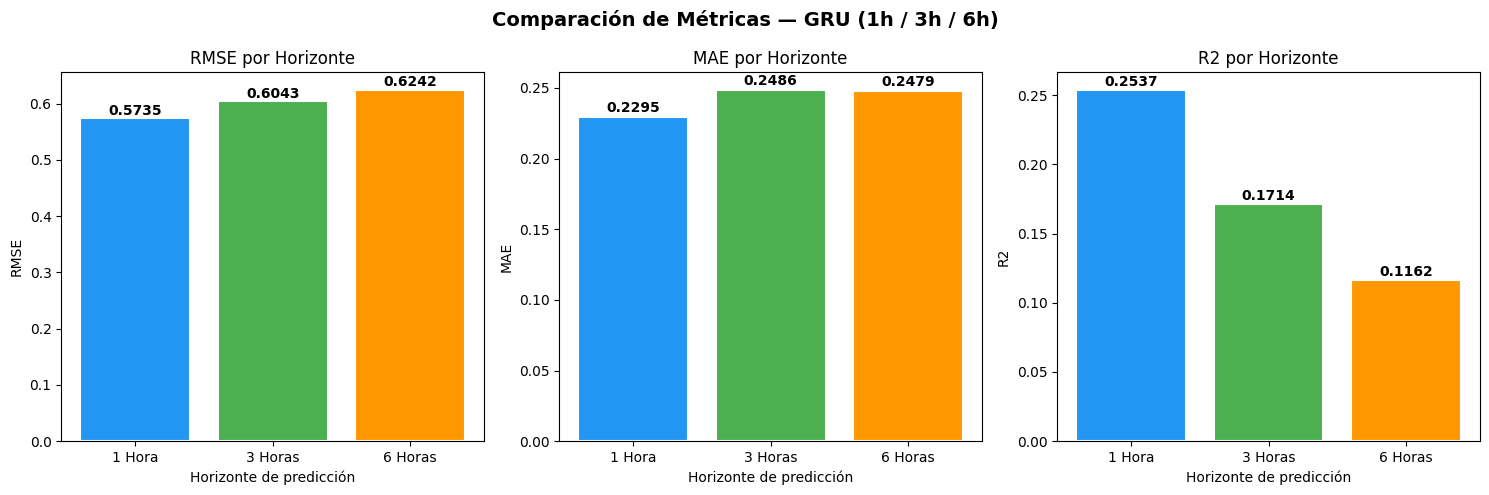

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    colors = ['#2196F3', '#4CAF50', '#FF9800']
    bars = ax.bar(results.index, results[metric], color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{metric} por Horizonte')
    ax.set_xlabel('Horizonte de predicción')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparación de Métricas — GRU (1h / 3h / 6h)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Guardado de Modelos

In [80]:
import joblib

model_1h.save('gru_model_1h.keras')
model_3h.save('gru_model_3h.keras')
model_6h.save('gru_model_6h.keras')

joblib.dump(scaler, 'scaler_JUN.pkl')

print('✅ Modelos y scaler guardados correctamente.')
print('   gru_model_1h.keras')
print('   gru_model_3h.keras')
print('   gru_model_6h.keras')
print('   scaler_JUN.pkl')

✅ Modelos y scaler guardados correctamente.
   gru_model_1h.keras
   gru_model_3h.keras
   gru_model_6h.keras
   scaler_JUN.pkl


---
## 📝 Resumen Metodológico

| Etapa | Detalle |
|---|---|
| **Resampleo** | 15 min → 1h: media para variables continuas, **suma** para lluvia |
| **Features** | AirTC, RH, SlrkW, NR_Wm2, WS_ms, LWmV + Rain (target) |
| **Ventana** | 24 horas previas (look_back = 24) |
| **Horizonte** | Multi-step: 1h / 3h / 6h |
| **Arquitectura** | GRU(64) → Dropout → GRU(32) → Dropout → Dense(horizon) |
| **Normalización** | MinMaxScaler [0,1], fit solo en train |
| **División** | 70% train / 15% val / 15% test (orden temporal) |
| **Callbacks** | EarlyStopping + ReduceLROnPlateau |
| **Post-proceso** | clip(0) para evitar precipitaciones negativas |